# 05 — Draft Strategy

**Goal:** Translate projections and VOR into actionable draft strategy.

**Note on ADP:** `nfl_data_py` does not include ADP data. Obtain ADP from:
- FantasyPros consensus ADP (free CSV download at fantasypros.com)
- Underdog Fantasy ADP
- Sleeper API

To use ADP analysis cells below, save your ADP CSV to `data/adp_2025.csv` with columns:
`player_name, position, team, adp`

Steps:
1. VOR analysis across league formats
2. Positional scarcity / value cliff analysis
3. ADP comparison (requires external ADP data)
4. Tier-based draft board
5. BREAKOUT / DECLINING player lists
6. Draft strategy recommendations

In [1]:
import sys
sys.path.insert(0, '..')
sys.path.insert(0, '../src')

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from config import PROJECTION_SEASON, POSITIONS, OUTPUT_DIR, PROJECT_ROOT
from models.vor import calculate_vor, calculate_vor_all_formats, get_replacement_levels
from ranking.ranker import generate_rankings, rankings_table
from ranking.tiers import assign_tiers_all_positions

# Load pre-generated projections from notebook 04
proj_path = OUTPUT_DIR / f'{PROJECTION_SEASON}_ppr_projections.csv'
if proj_path.exists():
    projections = pd.read_csv(proj_path)
    print(f'Loaded {len(projections)} projections from {proj_path}')
else:
    print('Run notebook 04 first to generate projections.')
    projections = None

Loaded 289 projections from c:\Data\Code\Fantasy Football\notebooks\..\output\projections\2025_ppr_projections.csv


## 1. VOR Across League Formats

In [2]:
if projections is not None:
    vor_formats = calculate_vor_all_formats(projections)
    
    print('Replacement levels by format:')
    for fmt, df in vor_formats.items():
        repl = df.groupby('position')['replacement_level'].first().round(1)
        print(f'\n{fmt}: {repl.to_dict()}')

Replacement levels by format:

10team: {'QB': 265.3, 'RB': 201.8, 'TE': 201.8, 'WR': 201.8}

12team: {'QB': 245.7, 'RB': 198.0, 'TE': 198.0, 'WR': 198.0}

14team: {'QB': 241.3, 'RB': 165.3, 'TE': 165.3, 'WR': 165.3}

12team_superflex: {'QB': 203.0, 'RB': 198.0, 'TE': 198.0, 'WR': 198.0}


## 2. Positional Scarcity — Value Cliff Analysis

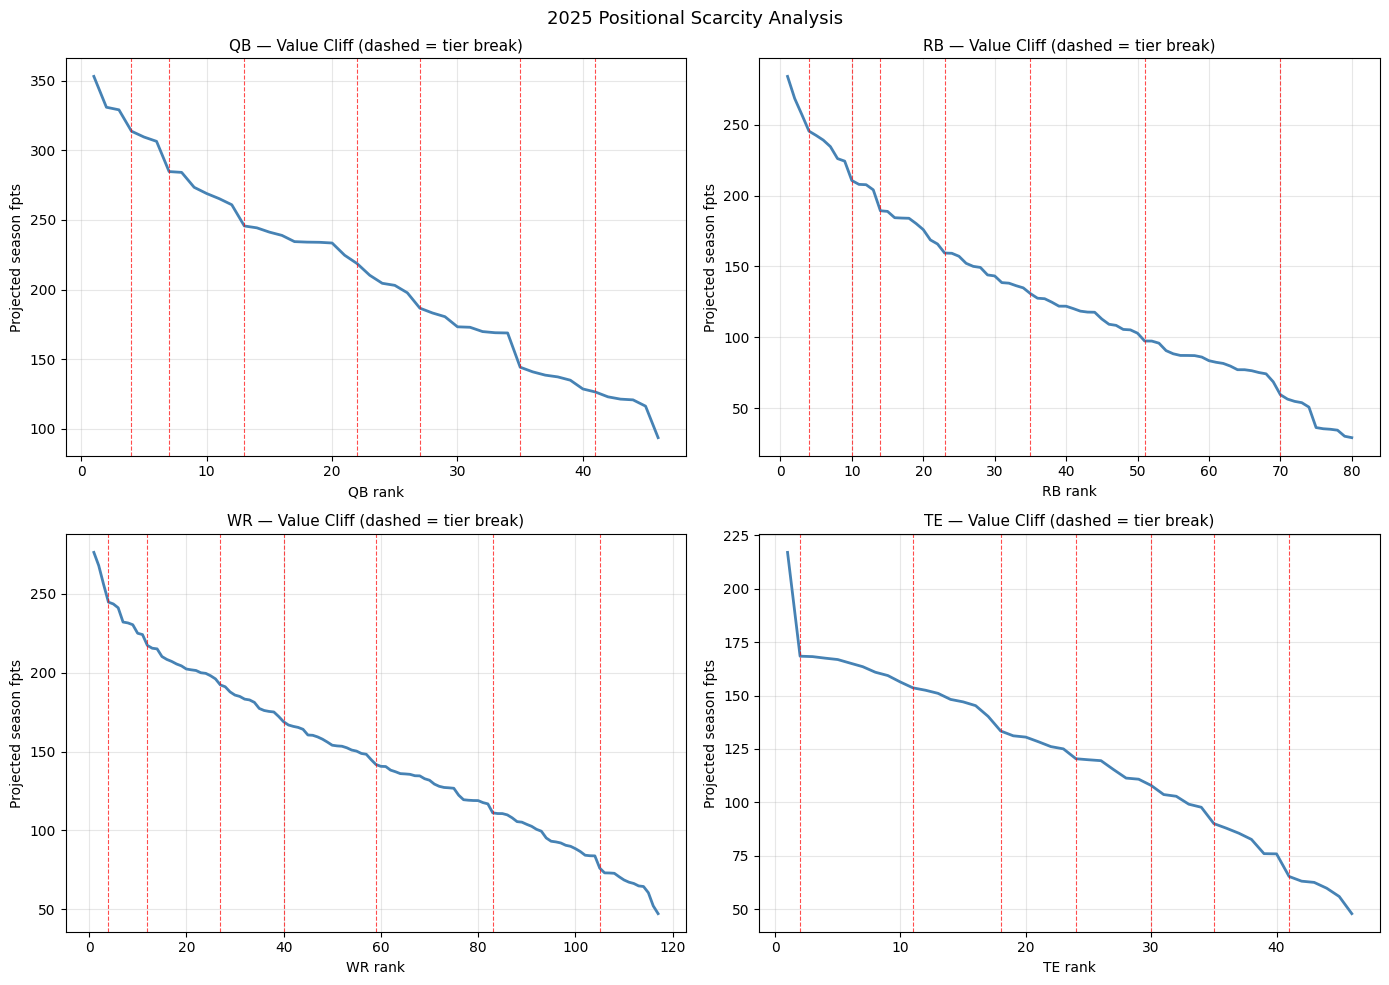

In [3]:
if projections is not None:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    for ax, pos in zip(axes.flat, POSITIONS):
        pos_df = projections[projections['position'] == pos].copy()
        pos_df = pos_df.sort_values('projected_fpts_season', ascending=False).reset_index(drop=True)
        
        if pos_df.empty:
            continue
        
        # Plot cumulative points available
        ax.plot(range(1, len(pos_df) + 1), pos_df['projected_fpts_season'].values,
                linewidth=2, color='steelblue')
        
        # Mark tier changes
        if 'tier' in pos_df.columns:
            tier_changes = pos_df[pos_df['tier'].diff().fillna(0) != 0].index
            for tc in tier_changes:
                ax.axvline(tc + 1, color='red', linewidth=0.8, linestyle='--', alpha=0.7)
        
        ax.set_xlabel(f'{pos} rank')
        ax.set_ylabel('Projected season fpts')
        ax.set_title(f'{pos} — Value Cliff (dashed = tier break)', fontsize=11)
        ax.grid(True, alpha=0.3)
    
    plt.suptitle(f'{PROJECTION_SEASON} Positional Scarcity Analysis', fontsize=13)
    plt.tight_layout()
    plt.show()

## 3. ADP Comparison

**Requires:** Save ADP data to `data/adp_2025.csv` with columns: `player_name, position, team, adp`

In [4]:
adp_path = PROJECT_ROOT / 'data' / 'adp_2025.csv'

if adp_path.exists() and projections is not None:
    adp = pd.read_csv(adp_path)
    adp['adp_rank'] = adp['adp'].rank(method='min').astype(int)
    
    # Fuzzy join on player_name + position
    proj_ranked = generate_rankings(projections)
    merged = proj_ranked.merge(
        adp[['player_name', 'position', 'adp', 'adp_rank']],
        on=['player_name', 'position'], how='inner'
    )
    
    # Value Over ADP (positive = undervalued by market)
    merged['voadp'] = merged['adp_rank'] - merged['overall_rank']
    
    print(f'Matched {len(merged)} players to ADP data')
    
    print('\nTop 15 VALUES (model rank >> ADP rank = underpriced):')
    values = merged.nlargest(15, 'voadp')[['player_name','position','team','overall_rank','adp_rank','voadp']]
    print(values.to_string(index=False))
    
    print('\nTop 15 REACHES (ADP rank >> model rank = overpriced):')
    reaches = merged.nsmallest(15, 'voadp')[['player_name','position','team','overall_rank','adp_rank','voadp']]
    print(reaches.to_string(index=False))
else:
    print(f'No ADP file found at {adp_path}')
    print('Save a CSV with columns [player_name, position, team, adp] to enable ADP comparison.')

No ADP file found at c:\Data\Code\Fantasy Football\notebooks\..\data\adp_2025.csv
Save a CSV with columns [player_name, position, team, adp] to enable ADP comparison.


## 4. Tiered Draft Board

In [5]:
if projections is not None:
    # Full tier-based draft board
    for pos in POSITIONS:
        pos_df = projections[projections['position'] == pos].copy()
        pos_df = pos_df.sort_values('projected_fpts_season', ascending=False)
        
        print(f'\n=== {pos} TIER BOARD ===')
        if 'tier' in pos_df.columns:
            for tier_num in sorted(pos_df['tier'].dropna().unique()):
                tier_players = pos_df[pos_df['tier'] == tier_num]
                names = ', '.join(tier_players['player_name'].fillna('Unknown').tolist())
                avg_pts = tier_players['projected_fpts_season'].mean()
                print(f'  Tier {tier_num} ({avg_pts:.0f} avg pts): {names}')


=== QB TIER BOARD ===
  Tier 1 (338 avg pts): Lamar Jackson, Jalen Hurts, Joe Burrow
  Tier 2 (310 avg pts): Baker Mayfield, Sam Darnold, Jared Goff
  Tier 3 (273 avg pts): Josh Allen, Patrick Mahomes, Tua Tagovailoa, Kyler Murray, Justin Herbert, Jordan Love
  Tier 4 (237 avg pts): Will Levis, Jayden Daniels, Bo Nix, Brock Purdy, Daniel Jones, Tyler Huntley, Gardner Minshew, Deshaun Watson, Mason Rudolph
  Tier 5 (207 avg pts): Justin Fields, Jameis Winston, Trevor Lawrence, Aidan O'Connell, Mac Jones
  Tier 6 (175 avg pts): Dak Prescott, Bryce Young, Drew Lock, C.J. Stroud, Drake Maye, Cooper Rush, Michael Penix Jr., Caleb Williams
  Tier 7 (137 avg pts): Russell Wilson, Geno Smith, Jacoby Brissett, Spencer Rattler, Derek Carr, Anthony Richardson
  Tier 8 (117 avg pts): Kirk Cousins, Joe Flacco, Matthew Stafford, Aaron Rodgers, Dorian Thompson-Robinson, Andy Dalton

=== RB TIER BOARD ===
  Tier 1 (270 avg pts): Jahmyr Gibbs, Bijan Robinson, Kenneth Walker III
  Tier 2 (235 avg pts):

## 5. BREAKOUT & DECLINING Players

In [6]:
if projections is not None and 'trend_class' in projections.columns:
    breakouts = projections[projections['trend_class'] == 'BREAKOUT'].sort_values('projected_fpts_season', ascending=False)
    decliners = projections[projections['trend_class'] == 'DECLINING'].sort_values('projected_fpts_season', ascending=False)
    
    print('BREAKOUT candidates (rising opportunity in late 2024):')
    if not breakouts.empty:
        print(breakouts[['player_name','position','team','projected_fpts_season','tier']].head(15).to_string(index=False))
    else:
        print('  (No BREAKOUT players detected)')
    
    print('\nDECLINING candidates (fading opportunity in late 2024):')
    if not decliners.empty:
        print(decliners[['player_name','position','team','projected_fpts_season','tier']].head(10).to_string(index=False))
else:
    print('trend_class column not available. Run detect_trends() in assembler.')

trend_class column not available. Run detect_trends() in assembler.


## 6. Draft Strategy Summary

### Interpreting This Board

1. **Follow VOR, not position bias.** Draft the player with the highest VORP available, regardless of position. VOR accounts for positional scarcity automatically.

2. **Tier breaks > positional runs.** Never skip a Tier 1 player to fill a positional need at Tier 2. The drop-off within a tier is small; the drop-off between tiers can be enormous.

3. **BREAKOUT players.** Players classified as BREAKOUT saw their opportunity share accelerating in the final 6 weeks. This is leading-indicator data. They are systematically undervalued by ADP tools that use full-season averages.

4. **Injury risk.** games_played history is in the feature matrix. Filter for players with < 13 games_played in 2024 and discount projections accordingly.

5. **Superflex:** QB VORP roughly doubles in superflex. In a standard league, QB scarcity is low — wait until Round 5+. In superflex, two elite QBs have significant long-term value.